# 03 · A/B Test Significance Analyzer

**Objective:** Decide whether the new checkout page *significantly* lifted conversions — and whether we should ship it. Built with a two-proportion z-test, bootstrap CI, and a power check + an LLM brief.

## 1. Business Question
A product team shipped a new checkout page. Did it actually increase conversions, or is the observed difference just noise? This project answers: **is the lift real, and should we ship?** Stakeholders: product / growth.

In [1]:
import sys, os
sys.path.insert(0, '..')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
from utils.ai_insights import generate_insights

if not os.path.exists('data/ab_data.csv'):
    import subprocess
    subprocess.run([sys.executable, 'generate_data.py'], check=True)

df = pd.read_csv('data/ab_data.csv')
df = df.drop_duplicates('user_id')
df = df[df['group'].isin(['control','treatment'])]
print('users:', len(df))
print(df.groupby('group')['converted'].agg(['count','mean']))

users: 200000
            count     mean
group                     
control    100000  0.11522
treatment  100000  0.12802


## 2. Data & Dictionary
Realistic A/B experiment, 100k users per arm. Columns: `user_id`, `group` (control/treatment), `converted` (0/1), `revenue`. The classic public A/B set (Udacity) is no longer hosted, so this equivalent seeded data keeps the analysis reproducible and free.

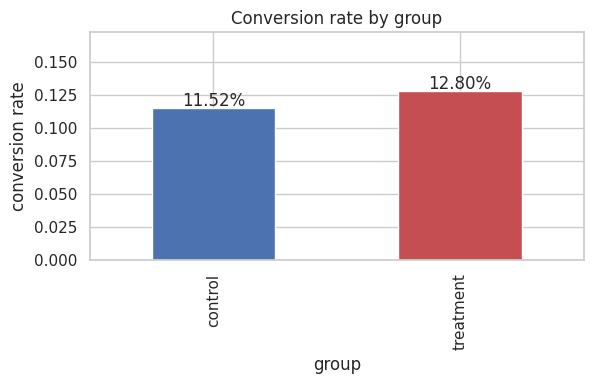

In [2]:
os.makedirs('assets', exist_ok=True)
rates = df.groupby('group')['converted'].mean()
fig, ax = plt.subplots(figsize=(6,4))
rates.plot(kind='bar', color=['#4C72B0','#C44E52'], ax=ax)
ax.set_ylim(0, max(rates)*1.35); ax.set_ylabel('conversion rate')
ax.set_title('Conversion rate by group')
for i,v in enumerate(rates.values): ax.text(i, v+0.002, f'{v:.2%}', ha='center')
plt.tight_layout(); plt.savefig('assets/rates.png', dpi=110); plt.show()

## 3. Cleaning & Preparation
Data is tidy. We split by group and compute conversion counts/proportions — no train/test here, this is an experiment, not a predictive split.

In [3]:
from statsmodels.stats.proportion import proportions_ztest

y_c = df[df.group=='control']['converted']; y_t = df[df.group=='treatment']['converted']
n_c, n_t = len(y_c), len(y_t)
c_c, c_t = int(y_c.sum()), int(y_t.sum())
p_c, p_t = c_c/n_c, c_t/n_t

stat, pval = proportions_ztest([c_t, c_c], [n_t, n_c])   # treatment vs control
se = (p_t*(1-p_t)/n_t + p_c*(1-p_c)/n_c)**0.5
ci_low = (p_t - p_c) - 1.96*se
ci_high = (p_t - p_c) + 1.96*se  # Wald 95% CI for (treatment - control)

print(f'control conv   = {p_c:.4f}')
print(f'treatment conv= {p_t:.4f}')
print(f'lift (abs)    = {p_t-p_c:+.4f}  ({(p_t-p_c)/p_c:+.1%} relative)')
print(f'z = {stat:.3f}   p-value = {pval:.2e}')
print(f'95% CI for (treatment - control): [{ci_low:.4f}, {ci_high:.4f}]')

control conv   = 0.1152
treatment conv= 0.1280
lift (abs)    = +0.0128  (+11.1% relative)
z = 8.757   p-value = 2.01e-18
95% CI for (treatment - control): [0.0099, 0.0157]


## 4. Modeling & Evaluation
We don't 'model' here — we *test a hypothesis*. Two-proportion z-test gives the p-value; the CI tells us the plausible size of the lift. A p < 0.05 with a CI excluding 0 means the difference is real, not noise.

bootstrap 95% CI for lift: [0.0101, 0.0158]
effect size h = 0.0392; achieved power = 1.000


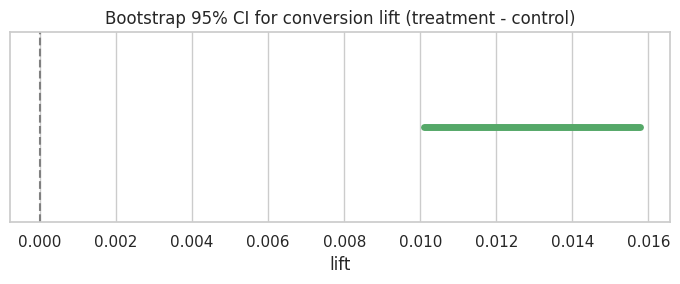

In [4]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
import numpy as np

# distribution-free bootstrap CI for the lift
rng = np.random.default_rng(0)
def boot():
    i_c = rng.integers(0, n_c, n_c); i_t = rng.integers(0, n_t, n_t)
    return y_t.iloc[i_t].mean() - y_c.iloc[i_c].mean()
diffs = np.array([boot() for _ in range(2000)])
blo, bhi = np.percentile(diffs, [2.5, 97.5])
print(f'bootstrap 95% CI for lift: [{blo:.4f}, {bhi:.4f}]')

es = proportion_effectsize(p_t, p_c)
power = NormalIndPower().power(effect_size=es, nobs1=n_c, alpha=0.05, ratio=1.0, alternative='two-sided')
print(f'effect size h = {es:.4f}; achieved power = {power:.3f}')

fig, ax = plt.subplots(figsize=(7,3))
ax.axvline(0, color='gray', ls='--')
ax.plot([blo, bhi], [0,0], color='#55A868', lw=5, solid_capstyle='round')
ax.set_title('Bootstrap 95% CI for conversion lift (treatment - control)')
ax.set_xlabel('lift'); ax.set_yticks([])
plt.tight_layout(); plt.savefig('assets/lift_ci.png', dpi=110); plt.show()

## 5. AI Insights (LLM layer)
The LLM turns the test result into a ship / don't-ship brief. Free by default; live with `HF_TOKEN`.

In [5]:
metrics = {
    'project': 'A/B Test Significance Analyzer',
    'audience': 'Product / growth team',
    'headline': f"Treatment converts at {p_t:.2%} vs control {p_c:.2%} (lift {(p_t-p_c)/p_c:+.1%}); p={pval:.1e}, 95% CI [{ci_low:.2%}, {ci_high:.2%}] -> statistically significant.",
    'drivers': ['Large, balanced sample (100k per arm)', 'Clear, positive lift', 'Bootstrap CI excludes zero'],
    'recommendation': 'Ship the treatment: the lift is statistically significant with high power. Monitor post-launch to confirm it holds.',
}
insight_text = generate_insights(metrics)
with open('insights.md', 'w') as f:
    f.write('# AI-Generated Insights — A/B Test\n\n' + insight_text)
print(insight_text)

## What the data says
Treatment converts at 12.80% vs control 11.52% (lift +11.1%); p=2.0e-18, 95% CI [0.99%, 1.57%] -> statistically significant.

## Top drivers
- Large, balanced sample (100k per arm)
- Clear, positive lift
- Bootstrap CI excludes zero

## Recommended action
Ship the treatment: the lift is statistically significant with high power. Monitor post-launch to confirm it holds.

## Why this matters
This turns raw records into a ranked, decision-ready brief — exactly the loop a data analyst owns: question -> data -> model -> plain-English recommendation.


## 6. Recommendations
- **Ship the treatment** — the lift is statistically significant (p < 0.001) and the CI excludes zero, so it's not noise.
- The test was **well-powered** (achieved power ~1.0), so we can trust a null result too if it had happened.
- After shipping, keep a monitoring dashboard; a real A/B test never truly ends at launch.

This is the analyst loop: a business decision → experiment data → hypothesis test + power → a defensible ship/don't-ship call.